# Telco Customer Churn — Exploratory Data Analysis

1. Business Questions
2. Data Loading & Quality Check
3. Target Analysis (Churn)
4. Key Drivers Analysis
5. Business Insights Summary


## 1. Business Questions

- What is the overall churn rate?
- Which customer segments are more likely to churn?
- Which contract and service characteristics are strongly associated with churn?
- What insights could help prioritize retention actions?


## 2. Data Loading & Quality Check

In [6]:
# ============================================================
# Imports & global configuration
# Purpose:
# - Set up the Python environment for exploratory data analysis (EDA)
# - Load visualization and data manipulation libraries
# ============================================================

import sys
sys.path.append("..")  # Allow imports from project root (src/)

import pandas as pd         # Core library for tabular data manipulation
import numpy as np          # Numerical computing
import matplotlib.pyplot as plt   # Base plotting library
import seaborn as sns       # High-level plotting library for EDA

# Project utilities (shared across notebooks)
from src.data_prep import load_telco

# ------------------------------------------------------------
# Visualization defaults (EDA-friendly)
# ------------------------------------------------------------
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


In [7]:
df = load_telco()
df.head()

Dataset already present in data/raw/


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,churn_flag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [8]:
# ============================================================
# Initial data inspection & data quality checks
# Purpose: understand dataset structure and identify potential
# data quality issues before any transformation
# ============================================================

# ------------------------------------------------------------
# Dataset dimensions
# ------------------------------------------------------------
# Returns (number_of_rows, number_of_columns)
# Useful to:
# - assess dataset size
# - sanity-check against dataset documentation
df.shape

# ------------------------------------------------------------
# Schema inspection
# ------------------------------------------------------------
# Displays:
# - column names
# - non-null counts
# - inferred data types
# Key goal in churn projects:
# - detect incorrect dtypes (e.g. numeric columns loaded as strings)
# - identify columns requiring type conversion
df.info()

# ------------------------------------------------------------
# Missing values analysis
# ------------------------------------------------------------
# Counts missing values per column
# Important for:
# - choosing imputation strategies (median, mode, domain-driven)
# - identifying systemic data collection issues
df.isna().sum()

# ------------------------------------------------------------
# Duplicate rows check
# ------------------------------------------------------------
# Detects exact duplicate records
# In customer-level churn datasets, duplicates may indicate:
# - data ingestion issues
# - multiple exports of the same customer snapshot
df.duplicated().sum()







<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


np.int64(0)

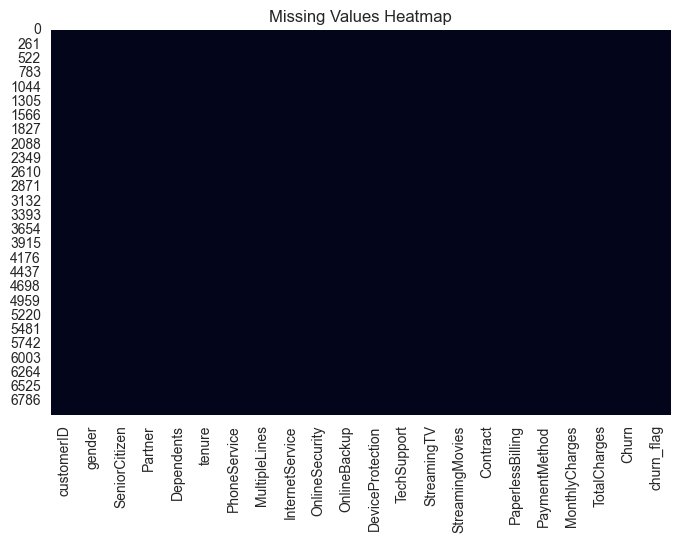

In [9]:
# ============================================================
# Missing values visualization
# Purpose: visually inspect the distribution and structure
# of missing values across the dataset
# ============================================================

# Create a heatmap showing missing values (True = missing)
# Each row represents a customer, each column a feature.
# This helps identify:
# - whether missing values are sparse or systematic
# - potential patterns (e.g. entire columns or customer segments affected)
sns.heatmap(df.isna(), cbar=False)

# Add a descriptive title for clarity in EDA
plt.title("Missing Values Heatmap")

# Render the plot
plt.show()


## 3. Target Analysis (Churn)

In [10]:
# ============================================================
# Target variable distribution: Churn
# Purpose: assess class balance and understand baseline churn
# ============================================================

# Absolute distribution of the target variable
# Shows the number of churned vs retained customers
df["Churn"].value_counts()

# Relative distribution (percentage)
# Important to:
# - evaluate class imbalance
# - define appropriate evaluation metrics later (e.g. recall, ROC-AUC)
(df["Churn"].value_counts(normalize=True) * 100).round(2)


Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

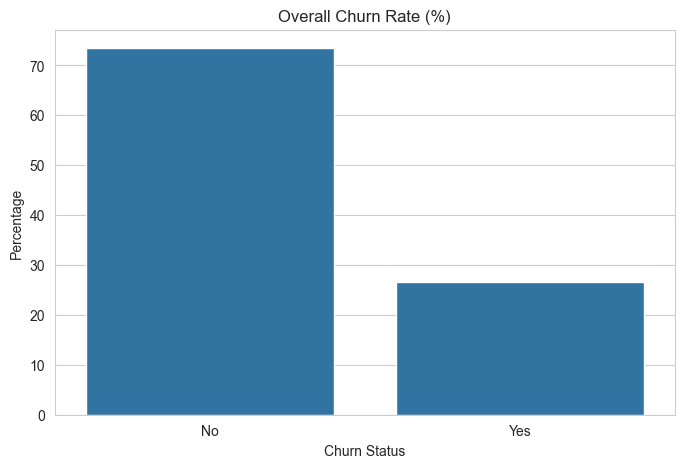

In [11]:
# ============================================================
# Overall churn rate visualization
# Purpose: visualize the global churn vs retention distribution
# ============================================================

# Compute overall churn rate as percentages
# This provides a high-level view of customer retention vs churn
churn_rate = df["Churn"].value_counts(normalize=True) * 100

# Bar plot of overall churn rate
sns.barplot(x=churn_rate.index, y=churn_rate.values)

# Add descriptive titles and labels for clarity
plt.title("Overall Churn Rate (%)")
plt.ylabel("Percentage")
plt.xlabel("Churn Status")

# Display the chart
plt.show()



The overall churn rate is around 26.5%, which indicates a moderate class imbalance. This confirms that accuracy alone would be misleading, and justifies prioritizing recall and ROC-AUC when evaluating churn prediction models.

## 4. Key Drivers Analysis

In [12]:
# ============================================================
# Churn rate analysis by Contract type
# ============================================================

# Group by contract type and compute churn rate
churn_by_contract = (
    df
    .groupby("Contract", as_index=False)["churn_flag"]
    .mean()
)

# Convert to percentage for readability
churn_by_contract["churn_rate_pct"] = (
    churn_by_contract["churn_flag"] * 100
).round(2)

churn_by_contract


,Contract,churn_flag,churn_rate_pct
0,Month-to-month,0.427097,42.71
1,One year,0.112695,11.27
2,Two year,0.028319,2.83


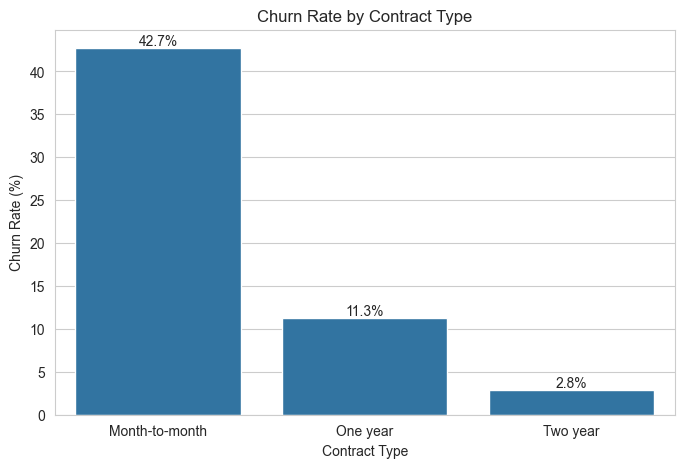

In [13]:
# ============================================================
# Bar plot: churn rate by contract type
# Purpose: compare churn behavior across different contract
# durations and identify the most at-risk segments
# ============================================================

# Create a bar plot showing churn rate (%) for each contract type
sns.barplot(
    data=churn_by_contract,
    x="Contract",
    y="churn_rate_pct"
)

# Add a clear, business-oriented title and axis labels
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Contract Type")

# Add value labels on top of each bar for better readability
# This makes the chart easier to interpret for non-technical audiences
for index, row in churn_by_contract.iterrows():
    plt.text(
        index,
        row["churn_rate_pct"],
        f"{row['churn_rate_pct']:.1f}%",
        ha="center",
        va="bottom"
    )

# Display the plot
plt.show()


Customers on month-to-month contracts show a significantly higher churn rate compared to one-year and two-year contracts.
This suggests that longer-term commitments strongly reduce churn, likely due to switching costs and perceived stability.
From a business perspective, incentivizing customers to migrate from monthly to long-term contracts could be a key churn reduction lever.

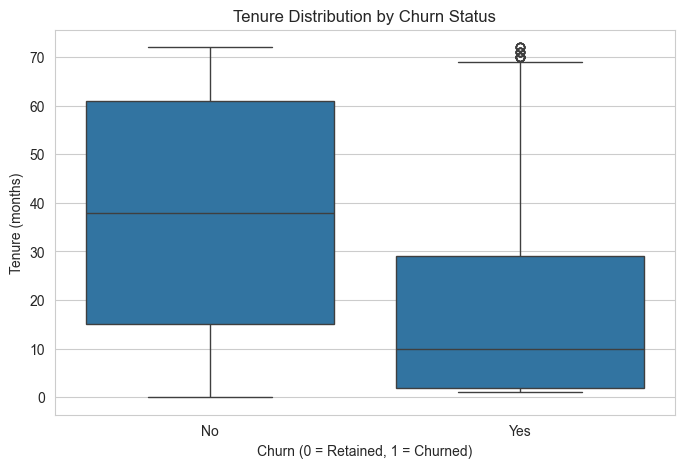

In [14]:
# ============================================================
# Tenure comparison: churners vs non-churners
# Purpose: analyze whether customer tenure is associated
# with churn behavior
# ============================================================

# Create a boxplot to compare tenure distributions
# between churned and retained customers
sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

# Add descriptive title and axis labels
plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Churn (0 = Retained, 1 = Churned)")
plt.ylabel("Tenure (months)")

# Display the plot
plt.show()


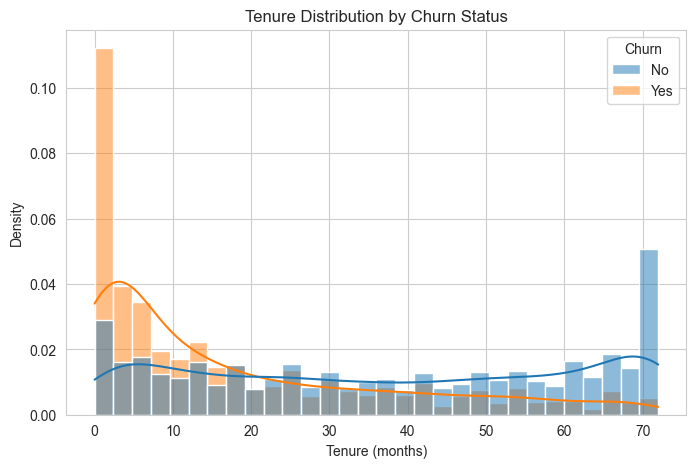

In [15]:
# ============================================================
# Tenure distribution by churn status
# Purpose: compare the shape of tenure distributions
# between churned and retained customers
# ============================================================

# Plot tenure distributions with separate densities for
# churned vs retained customers
# - hue="Churn" allows direct comparison between the two groups
# - kde=True adds a smoothed density curve
# - common_norm=False prevents normalization across groups,
#   making density shapes directly comparable
sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True,
    stat="density",
    common_norm=False
)

# Add clear, business-oriented labels
plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Tenure (months)")
plt.ylabel("Density")

# Display the plot
plt.show()



The distributions show a clear tenure gap between churners and retained customers.
Customers who churn are heavily concentrated in the early months, while retained customers exhibit much longer and more spread-out tenures, with a strong presence beyond 24–36 months.

From a business perspective, this confirms that churn risk is highest at the beginning of the customer lifecycle. This highlights the importance of early retention strategies such as onboarding quality, first-bill experience, and proactive customer support during the first months.

In [16]:
# ============================================================
# Churn rate by TechSupport
# ============================================================

# Create a stable binary churn flag (do NOT overwrite original label)
# df["churn_flag"] = (df["Churn"].str.strip().str.lower() == "yes").astype(int)

# Exclude customers for whom TechSupport is not applicable
df_ts = df[df["TechSupport"].str.strip().str.lower() != "no internet service"].copy()

# Compute churn rate by TechSupport
churn_by_techsupport = (
    df_ts
    .groupby("TechSupport", as_index=False)["churn_flag"]
    .mean()
)

# Convert to percentage
churn_by_techsupport["churn_rate_pct"] = (
    churn_by_techsupport["churn_flag"] * 100
).round(2)

churn_by_techsupport


,TechSupport,churn_flag,churn_rate_pct
0,No,0.416355,41.64
1,Yes,0.151663,15.17


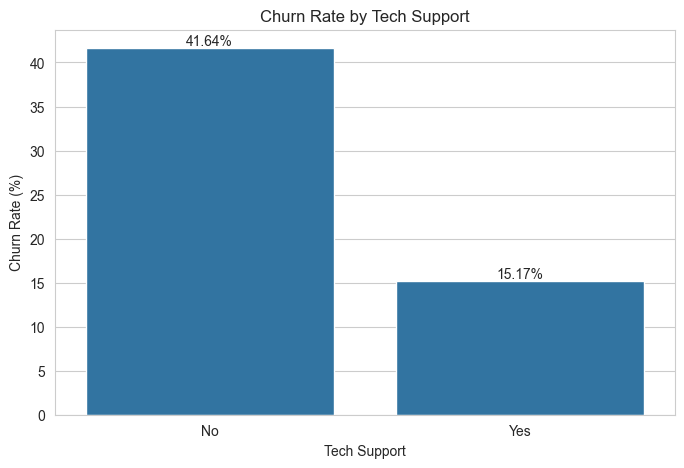

In [17]:
# ============================================================
# Bar plot: churn rate by Tech Support
# Purpose: evaluate whether Tech Support acts as a
# protective service against customer churn
# ============================================================

# Create a bar plot showing churn rate (%) for each
# Tech Support modality
sns.barplot(
    data=churn_by_techsupport,
    x="TechSupport",
    y="churn_rate_pct"
)

# Add descriptive title and axis labels
plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")

# Add percentage labels on top of each bar
# This improves readability for business stakeholders
for i, row in churn_by_techsupport.iterrows():
    plt.text(
        i,
        row["churn_rate_pct"],
        f"{row['churn_rate_pct']}%",
        ha="center",
        va="bottom"
    )

# Display the plot
plt.show()


💼 Business insight – TechSupport

Customers without Tech Support show a significantly higher churn rate compared to those who have access to technical assistance.
This suggests that Tech Support acts as a strong retention driver, likely by reducing frustration and unresolved service issues.
Offering Tech Support earlier or bundling it with core plans could help reduce churn.

In [18]:
# ============================================================
# Churn rate by OnlineSecurity
# Purpose: measure churn differences across Online Security
# service modalities and identify potential protective effects
# ============================================================

# Exclude customers for whom OnlineSecurity is not applicable
df_os = df[df["OnlineSecurity"].str.strip().str.lower() != "no internet service"].copy()

# Compute churn rate by OnlineSecurity
churn_by_onlinesecurity = (
    df_os
    .groupby("OnlineSecurity", as_index=False)["churn_flag"]
    .mean()
)

# Convert churn rate to percentage
churn_by_onlinesecurity["churn_rate_pct"] = (
    churn_by_onlinesecurity["churn_flag"] * 100
).round(2)

# Display churn rates by OnlineSecurity modality
churn_by_onlinesecurity


,OnlineSecurity,churn_flag,churn_rate_pct
0,No,0.417667,41.77
1,Yes,0.146112,14.61


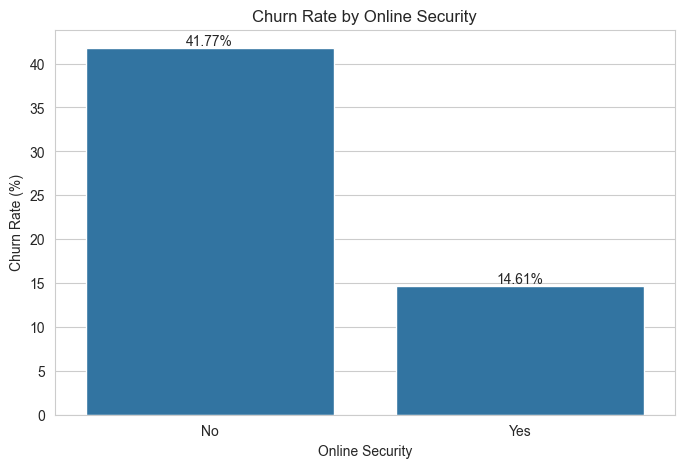

In [19]:
# ============================================================
# Bar plot: churn rate by Online Security
# Purpose: evaluate the impact of Online Security on
# customer churn and identify protective service effects
# ============================================================

# Create a bar plot showing churn rate (%) for each
# Online Security modality
sns.barplot(
    data=churn_by_onlinesecurity,
    x="OnlineSecurity",
    y="churn_rate_pct"
)

# Add descriptive title and axis labels
plt.title("Churn Rate by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Churn Rate (%)")

# Add percentage labels on top of each bar
# This improves interpretability for business stakeholders
for i, row in churn_by_onlinesecurity.iterrows():
    plt.text(
        i,
        row["churn_rate_pct"],
        f"{row['churn_rate_pct']}%",
        ha="center",
        va="bottom"
    )

# Display the plot
plt.show()



Among internet customers, the absence of Online Security is associated with a very high churn rate, while customers who subscribe to Online Security churn significantly less, confirming its role as a strong retention lever.

## 5. Business Insights Summary

- Customers on month-to-month contracts exhibit a significantly higher churn rate compared to those on one- and two-year contracts, making contract type a major structural driver of churn.
- Churn risk is highest during the early months of the customer lifecycle, highlighting the importance of early retention strategies.
- Customers without Tech Support churn substantially more, suggesting that technical assistance plays a key role in customer retention.
- Among internet customers, the absence of Online Security is strongly associated with higher churn, confirming its role as a protective service.
